<a href="https://colab.research.google.com/github/HFAJIR/GenAI_ML_Bootcamp/blob/main/Week4/Day_2/exercice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files


In [3]:
uploaded = files.upload()


Saving Student Mental health.csv to Student Mental health.csv


In [6]:
df = pd.read_csv("Student Mental health.csv")
df.head()


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [7]:
print(df.columns)

Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')


Step 2: Use Seaborn's histplot to create a histogram
We use sns.histplot to visualize the distribution of the CGPA ranges. Using discrete=True helps treat the categories correctly when plotting counts.

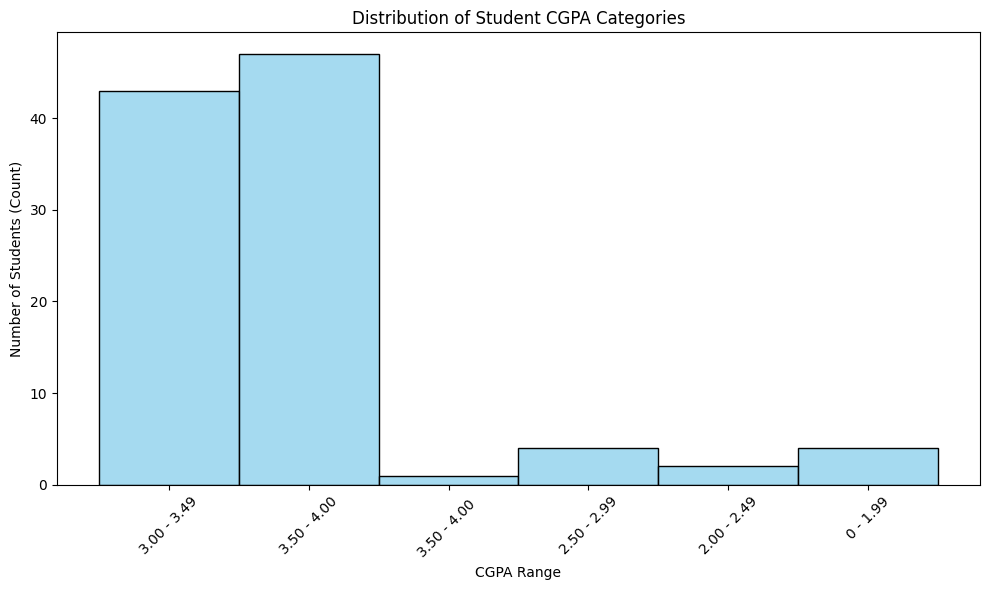

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='What is your CGPA?', discrete=True, color='skyblue')
plt.title('Distribution of Student CGPA Categories')
plt.xlabel('CGPA Range')
plt.ylabel('Number of Students (Count)')
plt.xticks(rotation=45) # Rotate labels for better fit
plt.tight_layout() # Adjust layout to make room for labels
plt.show()


**🌟 Exercise 2: Comparing Anxiety Levels Across Different Genders**

In [9]:
df['Do you have Anxiety?'] = df['Do you have Anxiety?'].replace('Nu', 'No')
df


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [10]:
unique_values = set(df['Choose your gender'])

print(unique_values)

{'Female', 'Male'}


/tmp/ipython-input-29697344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anxiety_yes, x='Choose your gender', y='proportion', palette='pastel', label="Gender qui repond Yes")


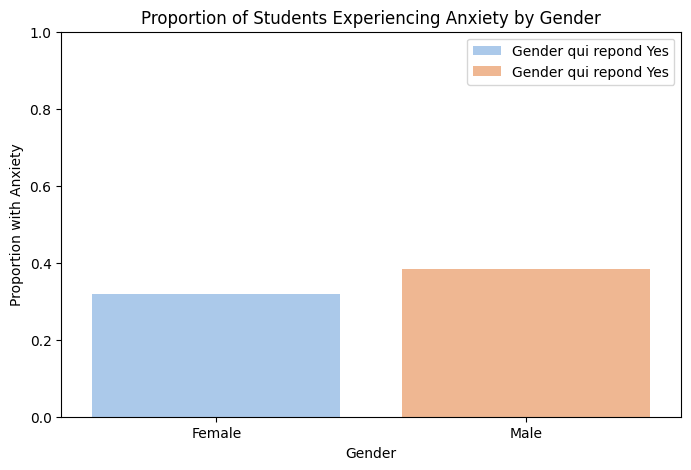

In [11]:

# Calculate proportions for 'Yes' anxiety responses
anxiety_proportions = df.groupby('Choose your gender')['Do you have Anxiety?'].value_counts(normalize=True).rename('proportion').reset_index()
anxiety_yes = anxiety_proportions[anxiety_proportions['Do you have Anxiety?'] == 'Yes']

# Create and customize the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(data=anxiety_yes, x='Choose your gender', y='proportion', palette='pastel', label="Gender qui repond Yes")
plt.title('Proportion of Students Experiencing Anxiety by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion with Anxiety')
plt.legend()
plt.ylim(0, 1)

# Display the plot
plt.show()

**🌟 Exercise 3: Exploring the Relationship Between Age and Panic Attacks**

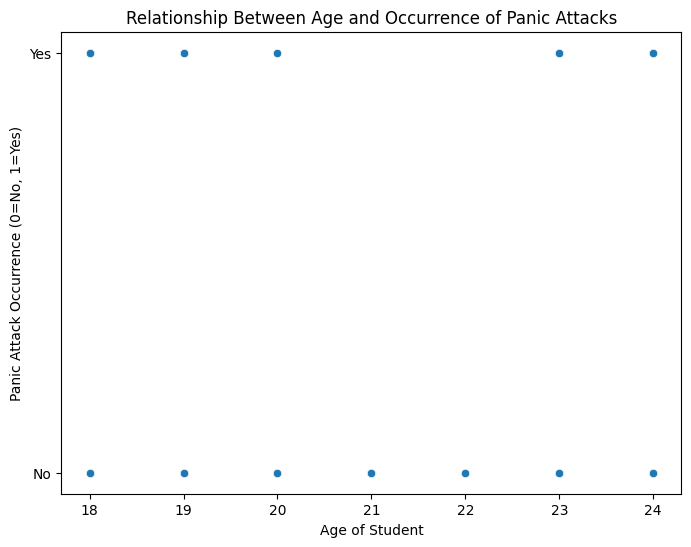

In [12]:
# 2. Convert 'Panic Attack' responses to numeric (Yes=1, No=0)
# This mapping allows the y-axis to be treated numerically for plotting.
df['Panic Attack Numeric'] = df['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})

# 3. Create the scatter plot
plt.figure(figsize=(8, 6)) # Optional: Adjusts plot size
sns.scatterplot(data=df, x='Age', y='Panic Attack Numeric')

# 4. Customize the plot to improve readability
plt.title('Relationship Between Age and Occurrence of Panic Attacks') # Add a title
plt.xlabel('Age of Student') # Label the x-axis
plt.ylabel('Panic Attack Occurrence (0=No, 1=Yes)') # Label the y-axis, clarifying the numeric scale

# Optional: Adjust y-axis ticks to show original labels
plt.yticks([0, 1], ['No', 'Yes'])

# 5. Display the plot
plt.show()

**🌟 Exercise 4: Visualizing Pairwise Relationships with Seaborn Pair Plot**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (5) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (5) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (5) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (5) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (5) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615:

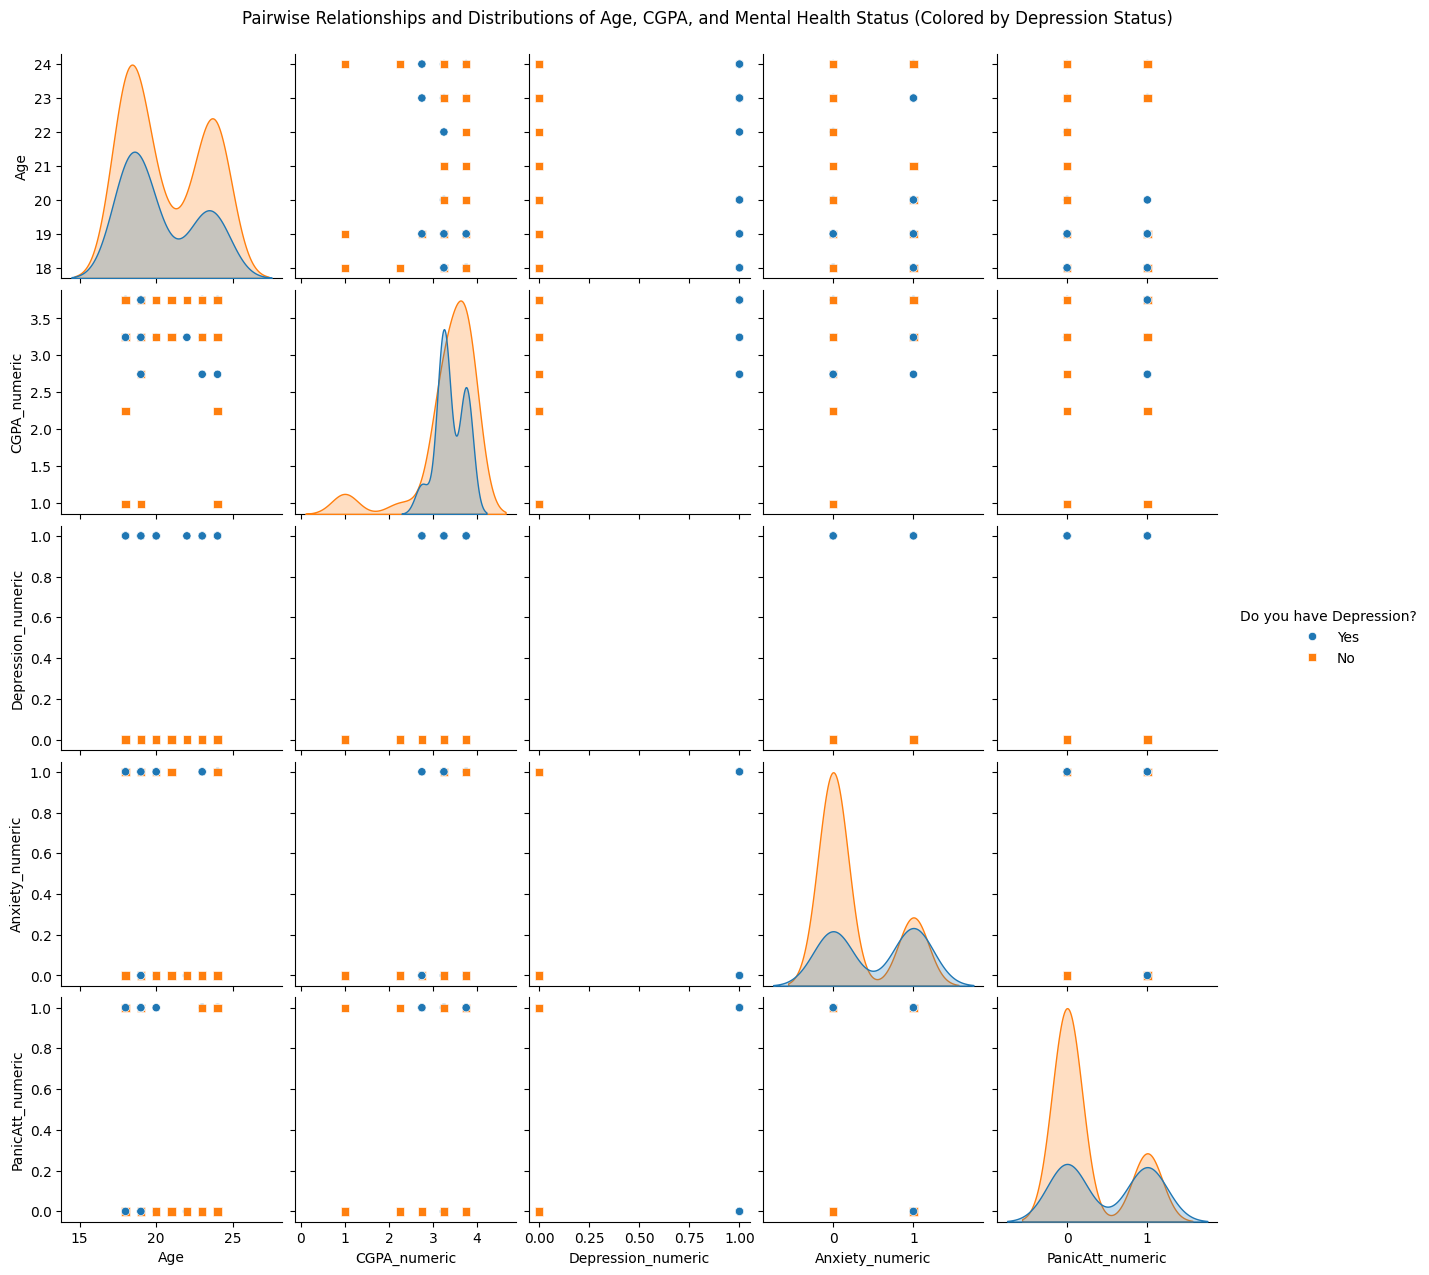

In [20]:
# For 'hue', we select 'Depression' as the categorical variable to color the points.
# Ensure the hue variable is treated as a category if it's coded numerically (e.g., 0/1) for better visualization.
# --- FIX: Convert categorical columns to numeric ---
# Map 'Yes' to 1 and 'No' to 0 for all relevant columns
mapping = {'Yes': 1, 'No': 0}
df['Depression_numeric'] = df['Do you have Depression?'].map(mapping)
df['Anxiety_numeric'] = df['Do you have Anxiety?'].map(mapping)
df['PanicAtt_numeric'] = df['Do you have Panic attack?'].map(mapping)
def convert_cgpa_range(x):
    low, high = x.split('-')
    return (float(low) + float(high)) / 2

df['CGPA_numeric'] = df['What is your CGPA?'].apply(convert_cgpa_range)
# --------------------------------------------------
# 2. Select a subset of columns relevant to the exercise

# 2. Select ONLY numeric columns for pairplot
selected_cols = [
    'Age',
    'CGPA_numeric',
    'Depression_numeric',
    'Anxiety_numeric',
    'PanicAtt_numeric'
]
# 3. Use Seaborn's pairplot to visualize pairwise relationships and distributions.
# Pass the full DataFrame and use the 'vars' parameter to select the columns to plot.
sns.pairplot(data=df,
             vars=selected_cols,
             hue='Do you have Depression?'
, # Color points based on depression status
             diag_kind='kde',  # Use Kernel Density Estimation for diagonal plots instead of default histogram
             markers=["o", "s", "D", "P", "X"]) # Use different markers for different categories

# Optional: Add a main title to the plot
plt.suptitle('Pairwise Relationships and Distributions of Age, CGPA, and Mental Health Status (Colored by Depression Status)', y=1.02) # Adjust y to prevent title overlap

# 4. Display the plot
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

**🌟 Exercise 5: Creating a Heatmap to Visualize Correlations**

In [25]:
# 1. Select the relevant numeric columns
# These columns are ready for correlation calculation


cols_for_correlation = ['Age', 'CGPA_numeric', 'Depression_numeric',
                        'Anxiety_numeric', 'PanicAtt_numeric']
df_subset = df[cols_for_correlation]


# 2. Calculate the correlation matrix
# Pandas calculates the Pearson correlation coefficient by default
corr_matrix = df_subset.corr()

# Print the matrix to the console to see the raw numbers
print("Correlation Matrix:")
print(corr_matrix)


Correlation Matrix:
                         Age  CGPA_numeric  Depression_numeric  \
Age                 1.000000      0.005610           -0.072171   
CGPA_numeric        0.005610      1.000000            0.041807   
Depression_numeric -0.072171      0.041807            1.000000   
Anxiety_numeric    -0.093661      0.172950            0.273764   
PanicAtt_numeric    0.055741      0.042511            0.246842   

                    Anxiety_numeric  PanicAtt_numeric  
Age                       -0.093661          0.055741  
CGPA_numeric               0.172950          0.042511  
Depression_numeric         0.273764          0.246842  
Anxiety_numeric            1.000000          0.084478  
PanicAtt_numeric           0.084478          1.000000  


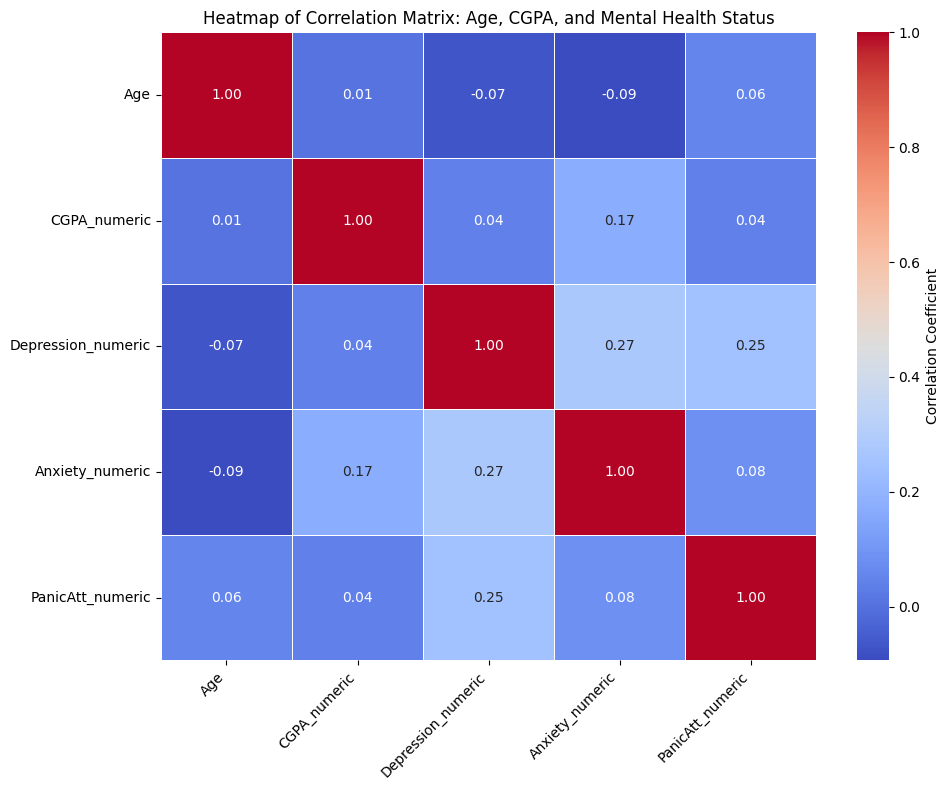

In [24]:
# 3. Use Seaborn’s heatmap function to visualize the correlation matrix
plt.figure(figsize=(10, 8)) # Adjust figure size for readability
sns.heatmap(
    corr_matrix,
    annot=True,      # Display the correlation coefficients on the heatmap cells
    fmt=".2f",       # Format annotations to two decimal places
    cmap='coolwarm', # Use a diverging colormap
    linewidths=.5,   # Add small lines between cells
    cbar_kws={'label': 'Correlation Coefficient'} # Label the color bar
)

# 4. Customize and display the plot
plt.title('Heatmap of Correlation Matrix: Age, CGPA, and Mental Health Status')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlap
plt.yticks(rotation=0)             # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to make room for rotated labels

plt.show()

**🌟 Exercise 6: Analyzing Distributions and Relationships Using FacetGrid**

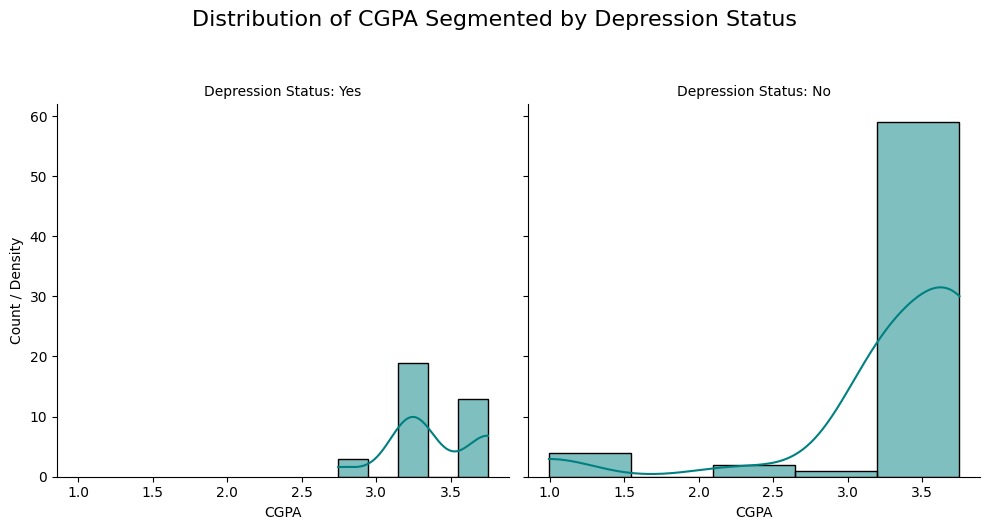

In [33]:
# Ensure CGPA is numeric
def convert_cgpa_range(x):
    low, high = x.split('-')
    return (float(low) + float(high)) / 2

df['CGPA_numeric'] = df['What is your CGPA?'].apply(convert_cgpa_range)
# ------------------------------------------------------------------

# 1. Initialize the FacetGrid
# We want one column for each depression status ('No' and 'Yes')
g = sns.FacetGrid(df, col='Do you have Depression?', height=5, aspect=1)

# 2. Map a histogram plot (or kdeplot for smooth density) to each facet
# We are plotting the 'what_is_your_cgpa' variable within each column
g.map(sns.histplot, 'CGPA_numeric', kde=True, bins=5, color='teal') # Use histplot with KDE overlay

# 3. Add titles and labels for clarity

# Add a main title to the entire grid
g.fig.suptitle('Distribution of CGPA Segmented by Depression Status', y=1.05, fontsize=16)

# Customize titles for each facet (e.g., changing 'col_name' to 'Depression Status: Yes/No')
g.set_titles("Depression Status: {col_name}")

# Add common x and y labels
g.set_axis_labels("CGPA", "Count / Density")

# Adjust layout to prevent overlap
g.tight_layout()

# Display the plot
plt.show()